[*********************100%***********************]  1 of 1 completed


Ticker          AAPL
2019-01-02       NaN
2019-01-03 -0.099608
2019-01-04  0.042689
2019-01-07 -0.002226
2019-01-08  0.019063


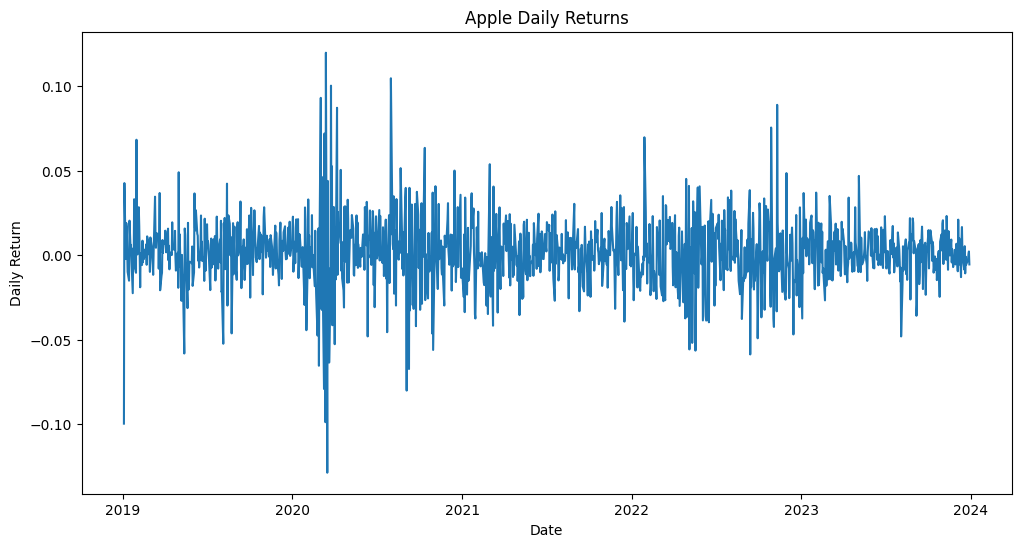

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# download Apple stock data
aapl = yf.download("AAPL", start="2019-01-01", end="2024-01-01")

# calculate daily percentage returns
returns = aapl["Close"].pct_change()

# looks at the first daily percentage returns
print(returns.head())

# plot returns
plt.figure(figsize=(12,6))
plt.plot(aapl.index, returns)
plt.title("Apple Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

The pct_change() method calculates the daily percentage return by finding the difference in the closing price's of the two days and then dividing by the original closing price.

In [2]:
print(returns.mean())
print(returns.std())

Ticker
AAPL    0.0015
dtype: float64
Ticker
AAPL    0.020306
dtype: float64


A higher mean is obviously better as that means on average the daily return is more. Typically a low standard deviation means the stock is less risky as there is less volatility meaning any losses are smaller but also any gains are smaller as well. However saying that even if the mean return is large but there is also large volatility it may not be beneficial as there is a lot more risk to the investment.

In [3]:
# download the data for the other 3 companies
msft = yf.download("MSFT", start="2019-01-01", end="2024-01-01")
nvda = yf.download("NVDA", start="2019-01-01", end="2024-01-01")
spy = yf.download("SPY", start="2019-01-01", end="2024-01-01")

#create a dataframe that stores a table of the daily returns for the 4 companies
returns_df = pd.DataFrame({
    "Apple": aapl["Close"].squeeze().pct_change(),
    "Microsoft": msft["Close"].squeeze().pct_change(),
    "Nvidia": nvda["Close"].squeeze().pct_change(),
    "S&P500": spy["Close"].squeeze().pct_change()
})

# calculate the means and standard deviations of the returns for the 4 companies
mean_returns = returns_df.mean()
volatility = returns_df.std()

# make another data frame storing these results 
summary = pd.DataFrame({
    "Mean Return": mean_returns,
    "Volatility": volatility
})

print(summary)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

           Mean Return  Volatility
Apple         0.001500    0.020306
Microsoft     0.001271    0.019207
Nvidia        0.002666    0.032612
S&P500        0.000664    0.013226


Nvidia have the highest mean returns however also having the highest volatility out of the four. This means if investors have higher risk tolerance they maybe prefer Nvidia however if they have a low risk tolerance they may go for the S&P500.